[View on GitHub](https://github.com/anojewel/siefdi/blob/assignment-2/notebooks/gauss_seidel.ipynb)

# Gauss Seidel for 1D Steady Heat Conduction
### CFD Assignment 2 Problem 2 and 3

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import inspect
import matplotlib.pyplot as plt

from src.geometry import RectangleSpace, CellCentredGrid
from src.fields import InternalScalarField, SimpleWallBC
from src.control_volume import Diffusion
from src.matrix_solver import SystemLinearEquations

In [2]:
# 1. The mathematical problem is the main thing being discussed here, we first make them using the workflow in assignment 1
# Instead of n=10, assignment 2 wants n=100 cells
rod_gridded = RectangleSpace([[0,0.5],[0,0.1],[0,0.1]]).grid('cell',[100])
heated_ends = SimpleWallBC(
    wall_values = [[100,500],[0,0],[0,0]],
    derivative_order= [[0,0],[1,1],[1,1]]
)
temperature_field = InternalScalarField(
    grid=rod_gridded,
    bcs=heated_ends
)
rod_problem = Diffusion(temperature_field, 100).assemble()

vars(rod_problem)

{'matrix': array([[ 600., -200.,    0., ...,    0.,    0.,    0.],
        [-200.,  400., -200., ...,    0.,    0.,    0.],
        [   0., -200.,  400., ...,    0.,    0.,    0.],
        ...,
        [   0.,    0.,    0., ...,  400., -200.,    0.],
        [   0.,    0.,    0., ..., -200.,  400., -200.],
        [   0.,    0.,    0., ...,    0., -200.,  600.]], shape=(100, 100)),
 'rhs_vector': array([ 40000.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.

Let $x^{(k)}$ be the $k$'th sweep, and so $x^{(k-1)}$ is the previous sweep. The guess starts from $x^{(k)}$ getting bitten by the zombie $x^{(k-1)}$:
$$ x^{(k)} = \begin{bmatrix} x^{(k)}_1 \\ x^{(k-1)}_2 \\ x^{(k-1)}_3 \\ \vdots \\ x^{(k-1)}_N \end{bmatrix} $$

Row 1 of $Ax = b$, multiplied with the vector above:
$$ \begin{bmatrix} A_{11} & A_{12} & A_{13} & \cdots & A_{1N} \end{bmatrix}
\begin{bmatrix} x^{(k)}_1 \\ x^{(k-1)}_2 \\ x^{(k-1)}_3 \\ \vdots \\ x^{(k-1)}_N \end{bmatrix} = b_1 $$

Multiplying out:
$$ A_{11}x^{(k)}_1 + A_{12}x^{(k-1)}_2 + A_{13}x^{(k-1)}_3 + \cdots + A_{1N}x^{(k-1)}_N = b_1 $$

Separating the diagonal term from the rest:
$$ A_{11}x^{(k)}_1 + \sum_{j=2}^{N} A_{1j}x^{(k-1)}_j = b_1 $$

Solving for $x^{(k)}_1$:
$$ x^{(k)}_1 = \frac{1}{A_{11}} \left( b_1 - \sum_{j=2}^{N} A_{1j}x^{(k-1)}_j \right) $$

Our zombified vector becomes, with $x^{(k)}_1$ now a known number and $x^{(k)}_2$ the next unknown:
$$ \begin{bmatrix} x^{(k)}_1 \\ x^{(k)}_2 \\ x^{(k-1)}_3 \\ \vdots \\ x^{(k-1)}_N \end{bmatrix} $$

Row 2 of $Ax = b$ with this vector:
$$ A_{21}x^{(k)}_1 + A_{22}x^{(k)}_2 + A_{23}x^{(k-1)}_3 + \cdots + A_{2N}x^{(k-1)}_N = b_2 $$

Solving for $x^{(k)}_2$:
$$ x^{(k)}_2 = \frac{1}{A_{22}} \left( b_2 - A_{21}x^{(k)}_1 - \sum_{j=3}^{N} A_{2j}x^{(k-1)}_j \right) $$

Continuing down to row $i$, everything above the diagonal entry is already new and everything below is still old:
$$ x^{(k)}_i = \frac{1}{A_{ii}} \left( b_i
- \underbrace{\sum_{j=1}^{i-1} A_{ij}x^{(k)}_j}_{\text{infected part}}
- \underbrace{\sum_{j=i+1}^{N} A_{ij}x^{(k-1)}_j}_{\text{not yet infected}} \right) $$
After row $N$, every entry is from sweep $k$, so the vector is fully $x^{(k)}$ and the next sweep starts.

In [3]:
# Shortening the name:
A = rod_problem.matrix
b = rod_problem.rhs_vector
# Assignment 2 asks for 100-s as our guess so we write it
x = np.full(len(b), 100.0)

In [4]:
# Iterate, this is the process of infection
def _infection():
    for i in range(len(b)):
        infected_part_of_x = A[i, :i] @ x[:i]        # columns before i: already this sweep
        healthy_part_of_x  = A[i, i+1:] @ x[i+1:]    # columns after i: still last sweep
        x[i] = (1/A[i,i])*(b[i] - infected_part_of_x - healthy_part_of_x)
    return x
print(_infection())
# It makes sense that everything is 100, because information runs from left to right. And since the left wall is 100 degrees.


[100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         100.         100.         100.         100.
 100.         

In [5]:
# Reset to the initial guess so the sweep count starts from zero
x = np.full(len(b), 100.0)

tolerance = 1e-6 #<--- this will be one of our input values
max_iterations = 100_000
changes = []                      # max |x^(k) - x^(k-1)| after every sweep

for k in range(1, max_iterations + 1):
    x_old = x.copy()              # frozen snapshot of the previous sweep
    _infection()                  # one sweep, updates x in place
    changes.append(np.max(np.abs(x - x_old)))
    if changes[-1] < tolerance:
        break

print(f"Converged after {k} sweeps, last change = {changes[-1]:.2e}")
print(x)


Converged after 12623 sweeps, last change = 1.00e-06
[101.9999837  105.99995116 109.99991869 113.99988634 117.99985413
 121.99982209 125.99979026 129.99975867 133.99972736 137.99969634
 141.99966565 145.99963532 149.99960538 153.99957586 157.99954678
 161.99951819 165.99949009 169.99946253 173.99943552 177.9994091
 181.99938329 185.99935811 189.99933359 193.99930975 197.99928662
 201.99926421 205.99924255 209.99922166 213.99920155 217.99918226
 221.99916379 225.99914617 229.9991294  233.99911351 237.99909851
 241.99908441 245.99907123 249.99905898 253.99904768 257.99903732
 261.99902792 265.99901949 269.99901204 273.99900556 277.99900008
 281.99899559 285.99899209 289.99898959 293.99898809 297.99898759
 301.99898809 305.99898959 309.99899208 313.99899557 317.99900004
 321.99900549 325.99901192 329.99901932 333.99902768 337.99903699
 341.99904724 345.99905843 349.99907052 353.99908353 357.99909742
 361.9991122  365.99912783 369.99914431 373.99916162 377.99917973
 381.99919864 385.999218

In [6]:
# Like in the TDMA notebook, we check the result against direct multiplication. This outputs A x - b
rod_problem_gs = SystemLinearEquations(A, b, x.copy())
rod_problem_gs.residual()
# Not as small as TDMA: we stopped when the sweeps stopped changing, not when the equations were exactly satisfied

array([-9.64775973e-06, -1.60605559e-05, -2.24511750e-05, -2.88133451e-05,
       -3.51408162e-05, -4.14273673e-05, -4.76668356e-05, -5.38531312e-05,
       -5.99801861e-05, -6.60420119e-05, -7.20327080e-05, -7.79464099e-05,
       -8.37773841e-05, -8.95199337e-05, -9.51685215e-05, -1.00717596e-04,
       -1.06161868e-04, -1.11495989e-04, -1.16714888e-04, -1.21813471e-04,
       -1.26786792e-04, -1.31630164e-04, -1.36338858e-04, -1.40908407e-04,
       -1.45334416e-04, -1.49612679e-04, -1.53739093e-04, -1.57709757e-04,
       -1.61520904e-04, -1.65168924e-04, -1.68650397e-04, -1.71962020e-04,
       -1.75100722e-04, -1.78063579e-04, -1.80847826e-04, -1.83450873e-04,
       -1.85870376e-04, -1.88104095e-04, -1.90150022e-04, -1.92006337e-04,
       -1.93671382e-04, -1.95143672e-04, -1.96421985e-04, -1.97505258e-04,
       -1.98392590e-04, -1.99083312e-04, -1.99576898e-04, -1.99873146e-04,
       -1.99971881e-04, -1.99873160e-04, -1.99577407e-04, -1.99085029e-04,
       -1.98396709e-04, -

Text(0, 0.5, '$\\max_i |x^{(k)}_i - x^{(k-1)}_i|$')

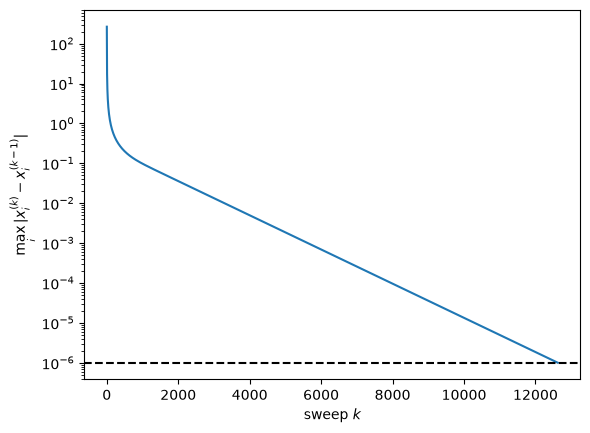

In [7]:
# How the change per sweep fell, on a log scale. The dashed line is the tolerance
plt.semilogy(range(1, len(changes) + 1), changes)
plt.axhline(tolerance, color='k', linestyle='--')
plt.xlabel('sweep $k$')
plt.ylabel(r'$\max_i |x^{(k)}_i - x^{(k-1)}_i|$')

### Problem 3: Comparison
Analytical solution from assignment 1, TDMA from Problem 1 and Gauss-Seidel from Problem 2 on the same figure.

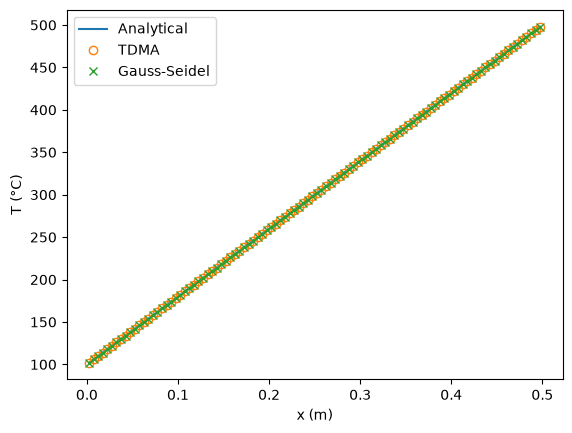

In [8]:
# Analytical solution from assignment 1:
T_exact = 100 + 800 * rod_gridded.centres[0]

# TDMA from Problem 1
rod_problem_tdma = rod_problem.thomas()

# Careful: x is already our Gauss-Seidel vector, so the cell positions get a different name here
centres = rod_gridded.centres[0]
plt.plot(centres, T_exact, label='Analytical')
plt.plot(centres, rod_problem_tdma.unknown_vector, 'o', mfc='none', label='TDMA')
plt.plot(centres, x, 'x', label='Gauss-Seidel')
plt.xlabel('x (m)')
plt.ylabel('T (°C)')
plt.legend()

In [9]:
# The plot can't show differences this small, so the numbers:
print(f"max |TDMA - exact|          = {np.max(np.abs(rod_problem_tdma.unknown_vector - T_exact)):.2e} °C")
print(f"max |Gauss-Seidel - exact|  = {np.max(np.abs(x - T_exact)):.2e} °C")
print(f"Gauss-Seidel sweeps needed  = {len(changes)}")

max |TDMA - exact|          = 7.28e-12 °C
max |Gauss-Seidel - exact|  = 1.01e-03 °C
Gauss-Seidel sweeps needed  = 12623


<!-- 🤖 [CLAUDE] draft, reword in your own words before submitting -->
#### Main difference between TDMA and Gauss-Seidel
- **TDMA is a direct method.** One forward sweep for $P_i, Q_i$ and one backward sweep for $x_i$, so it finishes in a fixed number of steps and gives the solution of the discretised equations up to round-off (residual around $10^{-11}$, max error $7 \times 10^{-12}$ °C). It only works for tridiagonal matrices.
- **Gauss-Seidel is an iterative method.** It starts from a guess ($100$ °C) and repeats sweeps, using each new value immediately, until $\max_i |x^{(k)}_i - x^{(k-1)}_i| < 10^{-6}$. Here it needed 12 623 sweeps, and the result is still off by about $1.0 \times 10^{-3}$ °C: a small change between sweeps does not mean a small error when each sweep only improves the solution a little. 

In [10]:
# All of the Gauss-Seidel code above is the copy inside this module:
print(inspect.getsource(SystemLinearEquations.gauss_seidel))

    def gauss_seidel(self, initial_guess, tolerance, max_iterations=100_000):
        """🤖 [CLAUDE] Solve the system by Gauss-Seidel sweeps, starting from initial_guess.

        initial_guess can be one number (used for every cell) or a full vector.
        Sweeps stop when max|x^(k) - x^(k-1)| < tolerance, or after max_iterations.
        Returns the solved SystemLinearEquations and the number of sweeps it took.
        """
        # Take the values from the class attribute
        matrix = self.matrix
        rhs = self.rhs_vector

        # Stretch a single number to every cell, and copy so the guess passed in is not overwritten
        unknown_vector = np.broadcast_to(initial_guess, rhs.shape).astype(float)

        for k in range(1, max_iterations + 1):
            previous_sweep = unknown_vector.copy() # frozen snapshot of the previous sweep
            # One sweep, this is the process of infection
            for i in range(len(rhs)):
                infected_part = matrix[i, :

Converged after 12623 sweeps
max |module - notebook loop| = 8.01e-12


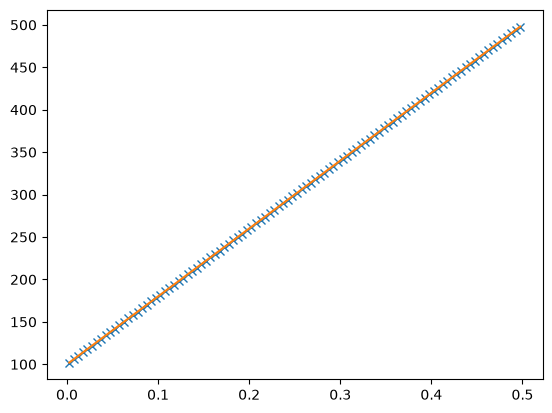

In [11]:
# So it should output the same thing
rod_problem_gs_module, n_sweeps = rod_problem.gauss_seidel(initial_guess=100, tolerance=1e-6)
print(f"Converged after {n_sweeps} sweeps")
print(f"max |module - notebook loop| = {np.max(np.abs(rod_problem_gs_module.unknown_vector - x)):.2e}")

plt.plot(centres, rod_problem_gs_module.unknown_vector, 'x')
plt.plot(centres, T_exact)